In [139]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.callbacks import CSVLogger

In [140]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


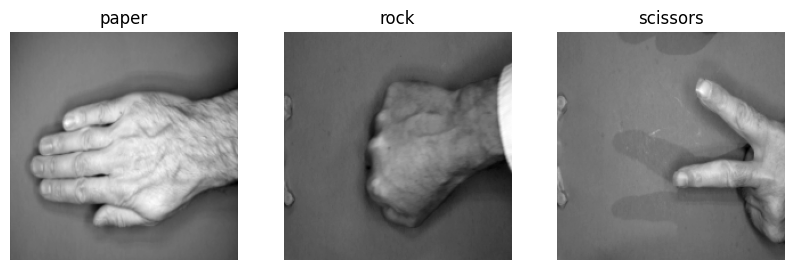

In [141]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [142]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
   
])

In [143]:

if os.path.exists("model_1.h5"):
    model_1 = keras.models.load_model("model_1.h5")
    history_1 = pd.read_csv('./training_1.log',sep=',',engine='python')
else:
    model_1 = keras.Sequential(
        [
        
        layers.Rescaling(1./255),
        layers.Resizing(96, 96),        
       layers.Conv2D(24, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(3,activation='softmax')
    
        ]
    )
    csv_logger_1 = CSVLogger('training_1.log', separator=',', append=False)
    model_1.summary()
    model_1.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_1=model_1.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger_1])
    history_1=history_1.history

Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


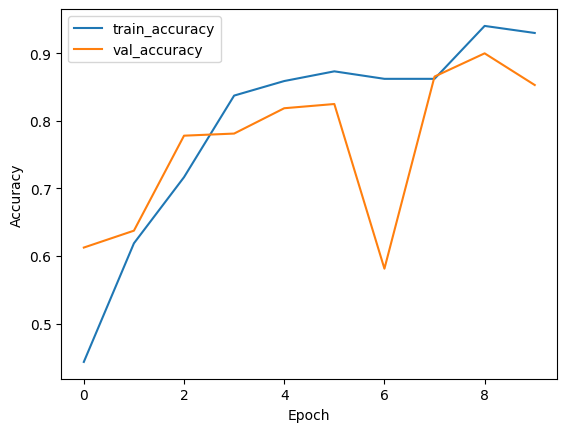

In [144]:
print(history_1.keys())
plt.plot(history_1["accuracy"], label="train_accuracy")
plt.plot(history_1["val_accuracy"], label="val_accuracy")
#plt.ylim(0.8, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
Predicted label: paper
Actual label: paper


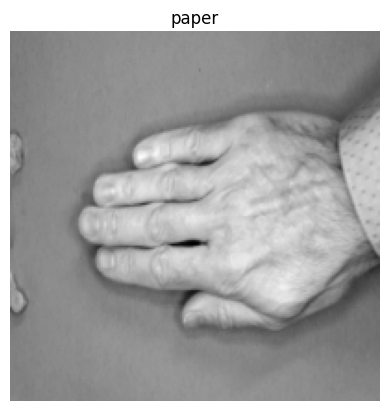

In [145]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [146]:
model_1.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8333 - loss: 0.4116


[0.41163545846939087, 0.8333333134651184]

In [147]:

if os.path.exists("model_2.h5"):
    model_2 = keras.models.load_model("model_2.h5")
    history_2 = pd.read_csv('./training_2.log',sep=',',engine='python')
else:
    model_2 = keras.Sequential(
        [
            data_augmentation,
        layers.Rescaling(1./255),
       layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal'),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(84, activation="relu",kernel_initializer='he_normal'),

        layers.Dense(3,activation='softmax')

        ]
    )
    csv_logger_2 = CSVLogger('training_2.log', separator=',', append=False)
    model_2.summary()

    model_2.compile(

            loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_2=model_2.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger_2])
    history_2=history_2.history

Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


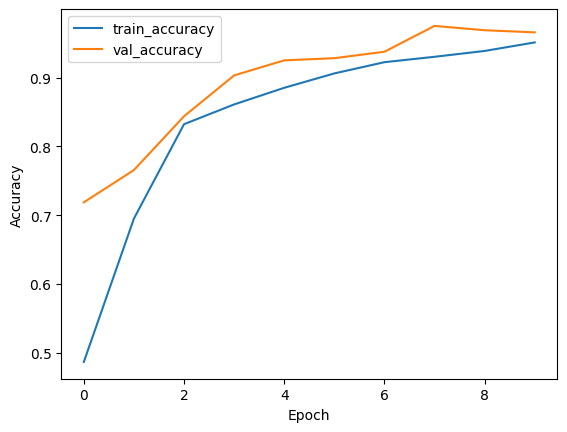

In [148]:
print(history_2.keys())
plt.plot(history_2["accuracy"], label="train_accuracy")
plt.plot(history_2["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [149]:
model_2.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9583 - loss: 0.1612


[0.16122086346149445, 0.9583333134651184]

In [150]:
if os.path.exists("model_3.h5"):
    model_3 = keras.models.load_model("model_3.h5")
    history_3 = pd.read_csv('./training_3.log',sep=',',engine='python')
else:
    model_3 = keras.Sequential([
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(16, (7, 7), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (5, 5), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),


        layers.Flatten(),
        layers.Dense(128, activation="relu",name='dense_1',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(64,activation='relu',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])
    csv_logger_3 = CSVLogger('training_3.log', separator=',', append=False)

    model_3.summary()
    model_3.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_3=model_3.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[csv_logger_3])
    history_3=history_3.history

Index(['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


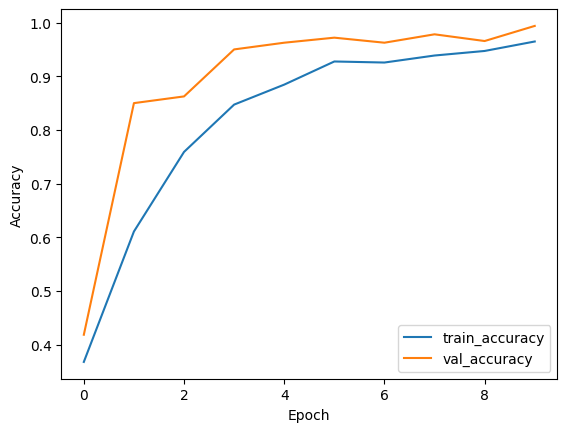

In [151]:
print(history_3.keys())
plt.plot(history_3["accuracy"], label="train_accuracy")
plt.plot(history_3["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted label: scissors
Actual label: scissors


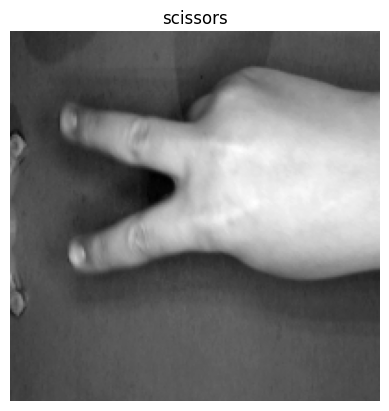

In [152]:

for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

In [197]:
y_test=[]
img_test=[]
y_pred_1=[]
y_pred_2=[]
y_pred_3=[]
for images, labels in test_ds.unbatch():
    y_test.append(labels.numpy())
    img_test.append(images.numpy())
    y_pred_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
    y_pred_2.append(np.argmax(model_2.predict(images[None, ...])[0]))
    y_pred_3.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_test = np.array(y_test)
img_test = np.array(img_test)
y_pred_1 = np.array(y_pred_1)
y_pred_2 = np.array(y_pred_2)
y_pred_3 = np.array(y_pred_3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━

In [199]:
result=confusion_matrix(y_test, y_pred_1)

In [200]:
incorrect_indices_1 = np.where(y_pred_1 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_1)} out of {len(y_test)}")

Incorrectly classified samples: 54 out of 336


In [201]:
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result,columns=class_names,index=class_names))
print(df)

                Predicted              
                    paper rock scissors
Actual paper           80    9        1
       rock             2  118        0
       scissors         5   37       84


In [202]:
result=confusion_matrix(y_test, y_pred_2)

In [203]:
incorrect_indices_2 = np.where(y_pred_2 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_2)} out of {len(y_test)}")

Incorrectly classified samples: 19 out of 336


In [204]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result,columns=class_names,index=class_names))

print(df)

              Predicted              
                  paper rock scissors
Real paper           79    2        9
     rock             5  112        3
     scissors         0    0      126


In [205]:

result=confusion_matrix(y_test, y_pred_3)

In [206]:
incorrect_indices_3 = np.where(y_pred_3 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_3)} out of {len(y_test)}")
print(incorrect_indices_3)

Incorrectly classified samples: 8 out of 336
[ 70  82 100 126 253 274 302 320]


In [208]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model3_cf=np.array(pd.DataFrame(result,columns=class_names,index=class_names))

print(df)

              Predicted              
                  paper rock scissors
Real paper           86    1        3
     rock             0  119        1
     scissors         2    1      123


0
2


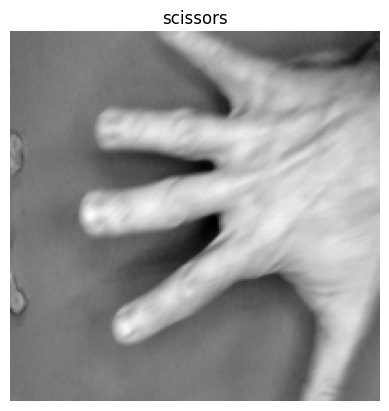

In [221]:
print(y_test[302])
print(y_pred_3[302])
img=img_test[302].squeeze()
plt.imshow(img, cmap="gray")
plt.title(class_names[y_pred_3[302]])
plt.axis("off")
plt.show()

In [209]:
m1_true_pos=np.diag(model1_cf)
m1_false_pos=np.sum(model1_cf, axis=0)-m1_true_pos
m1_false_neg=np.sum(model1_cf, axis=1)-m1_true_pos
m1_true_neg=np.sum(model1_cf)-m1_true_pos-m1_false_pos-m1_false_neg

m1_precision =m1_true_pos / (m1_true_pos + m1_false_pos)
m1_recall =m1_true_pos / (m1_true_pos + m1_false_neg)
m1_accuracy = np.sum(m1_true_pos) / np.sum(model1_cf)




In [210]:
print(f'------------------------model 1 performance metrics------------------------')
print(f'precision = {np.mean(m1_precision)}')
print(f'recall = {np.mean(m1_recall)}')
print(f'accuracy = {m1_accuracy}')


------------------------model 1 performance metrics------------------------
precision = 0.8757625730415519
recall = 0.8462962962962962
accuracy = 0.8392857142857143


In [211]:
m2_true_pos=np.diag(model2_cf)
m2_false_pos=np.sum(model2_cf, axis=0)-m2_true_pos
m2_false_neg=np.sum(model2_cf, axis=1)-m2_true_pos
m2_true_neg=np.sum(model2_cf)-m2_true_pos-m2_false_pos-m2_false_neg


m2_precision =m2_true_pos / (m2_true_pos + m2_false_pos)
m2_recall =m2_true_pos / (m2_true_pos + m2_false_neg)
m2_accuracy = np.sum(m2_true_pos) / np.sum(model2_cf)




In [212]:
print(f'------------------------model 2 performance metrics------------------------')
print(f'precision = {np.mean(m2_precision)}')
print(f'recall = {np.mean(m2_recall)}')
print(f'accuracy = {m2_accuracy}')


------------------------model 2 performance metrics------------------------
precision = 0.945325269695979
recall = 0.937037037037037
accuracy = 0.9434523809523809


In [213]:
m3_true_pos=np.diag(model3_cf)
m3_false_pos=np.sum(model3_cf, axis=0)-m3_true_pos
m3_false_neg=np.sum(model3_cf, axis=1)-m3_true_pos
m3_true_neg=np.sum(model3_cf)-m3_true_pos-m3_false_pos-m3_false_neg


m3_precision =m3_true_pos / (m3_true_pos + m3_false_pos)
m3_recall =m3_true_pos / (m3_true_pos + m3_false_neg)
m3_accuracy = np.sum(m3_true_pos) / np.sum(model3_cf)




In [214]:
print(f'------------------------model 3 performance metrics------------------------')
print(f'precision = {np.mean(m3_precision)}')
print(f'recall = {np.mean(m3_recall)}')
print(f'accuracy = {m3_accuracy}')

------------------------model 3 performance metrics------------------------
precision = 0.9764159128869222
recall = 0.9744708994708996
accuracy = 0.9761904761904762


In [215]:

if not os.path.exists("model_1.h5"):
        model_1.save("model_1.h5")
if not os.path.exists("model_2.h5"):
        model_2.save("model_2.h5")
if not os.path.exists("model_3.h5"):
        model_3.save("model_3.h5")